# Modelo 2 — Prevención de Fuga (Churn) con Clasificación Supervisada

**Modelos evaluados:** Random Forest · Gradient Boosting · Logistic Regression · XGBoost

**Selección:** maximizar `Recall × 0.60 + F1 × 0.40`

**Criterios de éxito:**
- Recall > 75% en clase Churn
- F1-Score > 0.70

## 1. Setup y paths

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_PATH  = '../data-base/ecommerce_customer_churn_dataset.csv'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Librerías

In [2]:
import pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
try:
    import xgboost as xgb; HAS_XGB = True
except ImportError:
    HAS_XGB = False; print('XGBoost no disponible.')
import importlib.util as _ilu
_spec=_ilu.spec_from_file_location('data_cleaning',
    os.path.join(PROJECT_ROOT,'src','dataMining','data_cleaning.py'))
_m=_ilu.module_from_spec(_spec); _spec.loader.exec_module(_m)
DataCleaner=_m.DataCleaner

XGBoost no disponible.


## 3. Carga y limpieza de datos

[LOAD] 50,000 registros cargados desde '../data-base/ecommerce_customer_churn_dataset.csv'
[QUALITY] Edad > 100 eliminados → quedan 47,485 (removed 2,515)
[QUALITY] Duplicados eliminados → quedan 47,485 (removed 0)
[OUTLIERS] Sin compras eliminados → quedan 47,440 (removed 45)
[OUTLIERS] Cart abandonment > 100.0 eliminados → quedan 47,412 (removed 28)
[OUTLIERS] AOV outliers (IQR ×1.5) eliminados → quedan 46,467 (removed 945)
[IMPUTE] Sin nulos restantes ✓
Dataset limpio: 46,467 registros | 25 columnas
Tasa de fuga: 28.7%  |  No churn: 71.3%


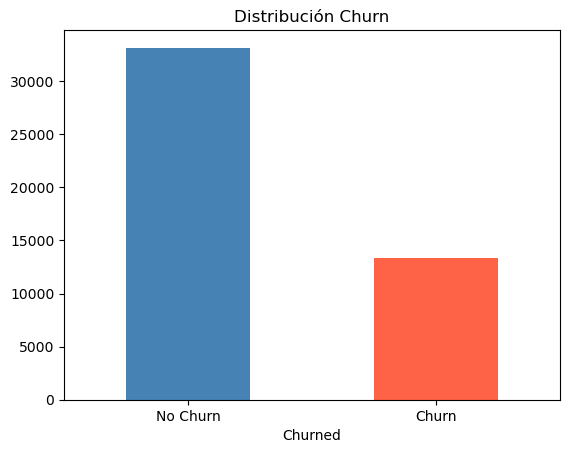

In [3]:
cleaner = DataCleaner(
    input_path=DATA_PATH,
    output_path=None,
    max_age=100,
    min_purchases=1,
    max_cart_rate=100.0,
    iqr_multiplier=1.5,
    impute_strategy='mean',
)
df = cleaner.run()
print(f'Dataset limpio: {df.shape[0]:,} registros | {df.shape[1]} columnas')

churn_pct = df['Churned'].mean() * 100
print(f'Tasa de fuga: {churn_pct:.1f}%  |  No churn: {100 - churn_pct:.1f}%')
df['Churned'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                   title='Distribución Churn')
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.show()

## 4. Selección de features y split

In [4]:
FEATURES = [
    'Login_Frequency', 'Cart_Abandonment_Rate', 'Returns_Rate',
    'Customer_Service_Calls', 'Days_Since_Last_Purchase',
    'Session_Duration_Avg', 'Pages_Per_Session', 'Discount_Usage_Rate',
    'Email_Open_Rate', 'Social_Media_Engagement_Score',
    'Membership_Years', 'Average_Order_Value',
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Features usadas ({len(FEATURES)}): {FEATURES}')

x = df[FEATURES]
y = df['Churned'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

print(f'Train: {x_train.shape[0]:,}  |  Test: {x_test.shape[0]:,}')

Features usadas (12): ['Login_Frequency', 'Cart_Abandonment_Rate', 'Returns_Rate', 'Customer_Service_Calls', 'Days_Since_Last_Purchase', 'Session_Duration_Avg', 'Pages_Per_Session', 'Discount_Usage_Rate', 'Email_Open_Rate', 'Social_Media_Engagement_Score', 'Membership_Years', 'Average_Order_Value']
Train: 37,173  |  Test: 9,294


## 5. Entrenamiento y evaluación de clasificadores

In [5]:
scale_pos = float((y==0).sum()) / max(float((y==1).sum()), 1.0)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_spaces = {
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'needs_scale': False,
        'params': {
            'n_estimators':    randint(100, 500),
            'max_depth':       randint(5, 20),
            'min_samples_leaf':randint(2, 15),
            'max_features':    ['sqrt', 'log2', 0.5],
        },
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=42),
        'needs_scale': False,
        'params': {
            'n_estimators': randint(100, 500),
            'max_depth':    randint(2, 8),
            'learning_rate':uniform(0.01, 0.25),
            'subsample':    uniform(0.6, 0.4),
        },
    },
    'Logistic Regression': {
        'estimator': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
        'needs_scale': True,
        'params': {
            'C':      uniform(0.01, 10),
            'penalty':['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
        },
    },
}
if HAS_XGB:
    param_spaces['XGBoost'] = {
        'estimator': xgb.XGBClassifier(scale_pos_weight=scale_pos,
            eval_metric='logloss', verbosity=0, random_state=42),
        'needs_scale': False,
        'params': {
            'n_estimators':     randint(100, 500),
            'max_depth':        randint(3, 9),
            'learning_rate':    uniform(0.01, 0.25),
            'subsample':        uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.5, 0.5),
            'gamma':            uniform(0, 5),
        },
    }

results = {}; best_name = ''; best_combined = -1.0
print(f'{"Modelo":<22} | {"Recall":>6} | {"F1":>6} | {"ROC-AUC":>7} | Estado')
print('-' * 62)

for name, cfg in param_spaces.items():
    x_tr = x_train_sc if cfg['needs_scale'] else x_train
    x_te = x_test_sc  if cfg['needs_scale'] else x_test

    search = RandomizedSearchCV(
        cfg['estimator'], cfg['params'],
        n_iter=15, scoring='recall', cv=cv,
        n_jobs=-1, random_state=42, refit=True,
    )
    search.fit(x_tr, y_train)
    clf     = search.best_estimator_
    y_pred  = clf.predict(x_te)
    y_proba = clf.predict_proba(x_te)[:, 1]

    recall  = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    combined = recall * 0.60 + f1 * 0.40
    status   = '✓ CUMPLE' if (recall > 0.75 and f1 > 0.70) else '⚠'
    print(f'{name:<22} | {recall:>6.3f} | {f1:>6.3f} | {roc_auc:>7.4f} | {status}')
    print(f'  Best params: {search.best_params_}')

    results[name] = dict(
        recall=round(recall,4), f1=round(f1,4), roc_auc=round(roc_auc,4),
        model=clf, needs_scale=cfg['needs_scale'],
        best_params=search.best_params_,
        y_pred=y_pred, y_proba=y_proba,
    )
    if combined > best_combined:
        best_combined = combined; best_name = name

print(f'\n► Mejor modelo: {best_name}')

Modelo                 | Recall |     F1 | ROC-AUC | Estado
--------------------------------------------------------------


Random Forest          |  0.734 |  0.652 |  0.8299 | ⚠
  Best params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 13, 'n_estimators': 113}


Gradient Boosting      |  0.593 |  0.669 |  0.8497 | ⚠
  Best params: {'learning_rate': np.float64(0.12401749605425898), 'max_depth': 7, 'n_estimators': 150, 'subsample': np.float64(0.7529847965068651)}


Logistic Regression    |  0.682 |  0.562 |  0.7520 | ⚠
  Best params: {'C': np.float64(3.7554011884736247), 'penalty': 'l1', 'solver': 'liblinear'}

► Mejor modelo: Random Forest


## 6. Análisis del mejor modelo

Modelo: Random Forest
Recall : 0.7336  ⚠
F1     : 0.6524  ⚠
ROC-AUC: 0.8299

              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      6629
       Churn       0.59      0.73      0.65      2665

    accuracy                           0.78      9294
   macro avg       0.73      0.76      0.74      9294
weighted avg       0.80      0.78      0.78      9294



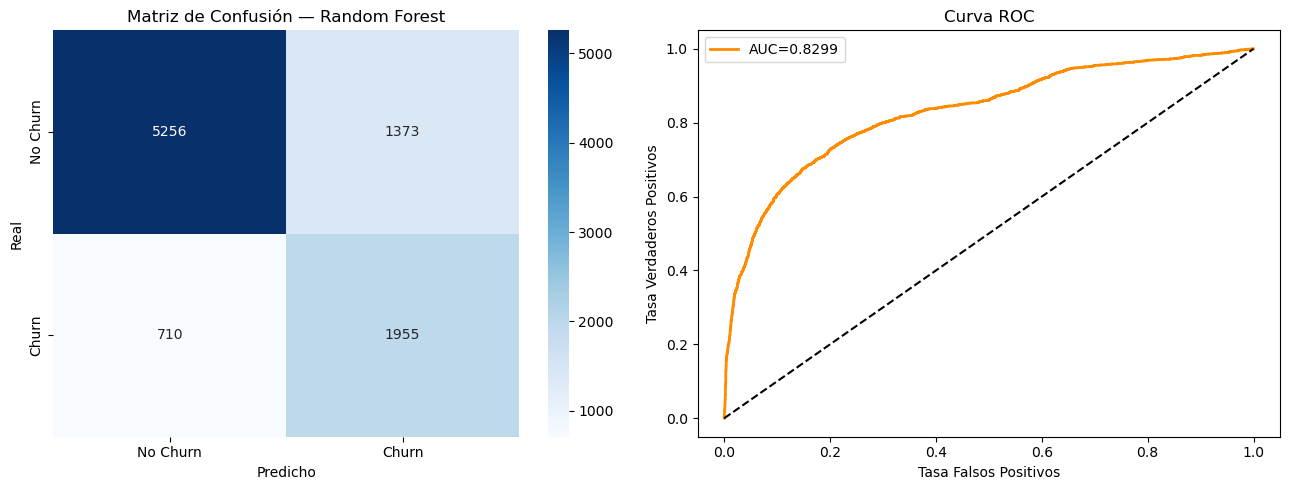

In [6]:
best = results[best_name]
print(f'Modelo: {best_name}')
print(f'Recall : {best["recall"]:.4f}  {"✓" if best["recall"] > 0.75 else "⚠"}')
print(f'F1     : {best["f1"]:.4f}  {"✓" if best["f1"] > 0.70 else "⚠"}')
print(f'ROC-AUC: {best["roc_auc"]:.4f}')
print()
print(classification_report(y_test, best['y_pred'], target_names=['No Churn','Churn']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title(f'Matriz de Confusión — {best_name}')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, best['y_proba'])
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={best["roc_auc"]:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Tasa Falsos Positivos')
axes[1].set_ylabel('Tasa Verdaderos Positivos')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Importancia de features

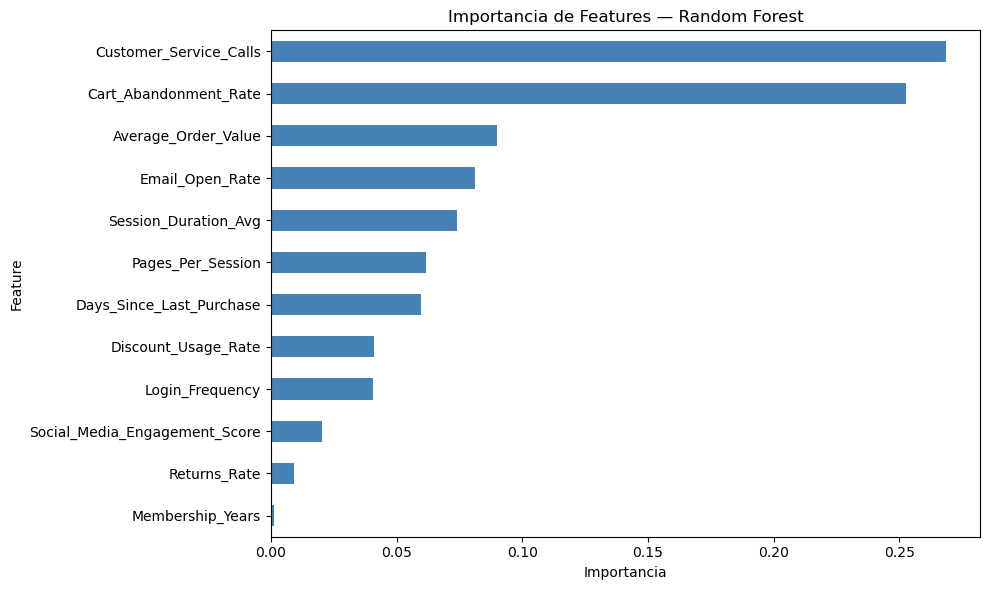

In [7]:
model = best['model']
feat_importance = {}

if hasattr(model, 'feature_importances_'):
    feat_importance = dict(sorted(
        zip(FEATURES, model.feature_importances_),
        key=lambda z: z[1], reverse=True
    ))
    fi_df = pd.DataFrame(feat_importance.items(), columns=['Feature', 'Importancia'])
    fi_df.plot(x='Feature', y='Importancia', kind='barh', figsize=(10, 6),
               color='steelblue', legend=False)
    plt.title(f'Importancia de Features — {best_name}')
    plt.xlabel('Importancia')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif hasattr(model, 'coef_'):
    feat_importance = dict(zip(FEATURES, abs(model.coef_[0])))
    print('Coeficientes (valor absoluto):', feat_importance)

## 8. Exportar modelo

Exporta el mejor clasificador, el scaler y metadatos a `../models/churn_model.pkl`.

In [8]:
churn_bundle = {
    'model':             best['model'],
    'scaler':            scaler,
    'needs_scale':       best['needs_scale'],
    'features':          FEATURES,
    'model_name':        best_name,
    'recall':            best['recall'],
    'f1':                best['f1'],
    'roc_auc':           best['roc_auc'],
    'best_params':       best.get('best_params', {}),
    'feature_importance': feat_importance,
    'all_results': {n:{'recall':v['recall'],'f1':v['f1'],'roc_auc':v['roc_auc']}
                    for n,v in results.items()},
}
out_path = os.path.join(MODELS_DIR, 'churn_model.pkl')
with open(out_path, 'wb') as f: pickle.dump(churn_bundle, f)
print(f'Modelo Churn exportado -> {out_path}')
print(f'  {best_name} | Recall={best["recall"]:.4f} | F1={best["f1"]:.4f} | AUC={best["roc_auc"]:.4f}')
print(f'  Best params: {best.get("best_params", {})}')

Modelo Churn exportado -> ../models/churn_model.pkl
  Random Forest | Recall=0.7336 | F1=0.6524 | AUC=0.8299
  Best params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 13, 'n_estimators': 113}
